# 🏠 House Price Prediction

## Project Overview
This notebook focuses on analyzing housing data and building a machine learning model to predict house prices based on various features such as location, size, number of rooms, and other property characteristics.

## Objectives
- Perform exploratory data analysis (EDA) to understand key factors affecting house prices
- Handle missing values and outliers
- Engineer meaningful features
- Train and evaluate regression models
- Compare model performance using appropriate metrics

## Dataset Description
The dataset contains information related to residential properties, including:
- Property size and layout
- Location-based attributes
- Price-related features
- Additional numerical and categorical variables

## Workflow
1. Data Loading and Inspection  
2. Data Cleaning and Preprocessing  
3. Exploratory Data Analysis (EDA)  
4. Feature Engineering  
5. Model Training  
6. Model Evaluation  
7. Conclusion and Insights

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

---


In [9]:
import pandas as pd, numpy as np, math
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from transformers import DropColumns,feature_ordinal_encoding,featureEngineering,LogTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor,XGBRFRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from Evaluations import evaluate,print_model_rmse
from sklearn.metrics import r2_score, mean_squared_error

In [10]:
train = pd.read_csv('../Data/train.csv')
test = pd.read_csv('../Data/test.csv')

## Data Overview

## 📋 Dataset Column Descriptions
---
| Category | Column Name | Description |
|--------|------------|-------------|
| Identifier | `id` | Unique identifier for each property |
| Sale Info | `date` | Date when the property was sold |
| Price | `price` | Final sale price of the house |
| Property Features | `bedrooms` | Number of bedrooms in the house |
| Property Features | `bathrooms` | Number of bathrooms (including partial bathrooms as fractions) |
| Property Features | `sqft_living` | Total living area in square feet |
| Property Features | `sqft_lot` | Total lot size in square feet |
| Property Features | `floors` | Number of floors in the house |
| Property Features | `waterfront` | Indicates whether the property has a waterfront view |
| Property Features | `view` | Quality rating of the property's view |
| Property Features | `condition` | Overall condition rating of the house |
| Property Features | `grade` | Construction and design quality (scale: 1–13) |
| Additional Metrics | `sqft_above` | Living area above ground level (in sq. ft.) |
| Additional Metrics | `sqft_basement` | Basement area in square feet |
| Additional Metrics | `yr_built` | Year the house was originally constructed |
| Additional Metrics | `yr_renovated` | Year of the most recent renovation (0 if never renovated) |
| Location | `zipcode` | ZIP code of the property |
| Location | `lat` | Latitude coordinate |
| Location | `long` | Longitude coordinate |
| Neighbor Stats | `sqft_living15` | Average living area of the 15 nearest neighboring properties |
| Neighbor Stats | `sqft_lot15` | Average lot size of the 15 nearest neighboring properties |

---

##  Samples rows

In [11]:
train.sample(5)

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
1789,7820000038,20141114T000000,3,2.00,1700,10000,2.0,N,0,Average,...,1700,0,1992,0,98011,47.7661,-122.205,1460,9621,454000.0
6613,1324059139,20140918T000000,3,2.25,1960,10385,1.0,N,0,Average,...,1960,0,1988,0,98008,47.5736,-122.109,2800,12632,613000.0
657,1774350160,20140718T000000,4,2.50,2340,41600,1.0,N,0,Average,...,1640,700,1977,0,98077,47.7466,-122.077,2340,34960,522250.0
9498,5029451080,20140821T000000,2,1.00,1440,6650,1.0,N,0,Average,...,970,470,1980,0,98023,47.2896,-122.369,1600,6847,203000.0
3756,1331900110,20141008T000000,4,2.50,2960,28005,2.0,N,0,Average,...,2960,0,1989,0,98072,47.7477,-122.117,3510,35248,760000.0


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14480 entries, 0 to 14479
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             14480 non-null  int64  
 1   date           14480 non-null  object 
 2   bedrooms       14480 non-null  int64  
 3   bathrooms      14480 non-null  float64
 4   sqft_living    14480 non-null  int64  
 5   sqft_lot       14480 non-null  int64  
 6   floors         14480 non-null  float64
 7   waterfront     14480 non-null  object 
 8   view           14480 non-null  int64  
 9   condition      14480 non-null  object 
 10  grade          14480 non-null  int64  
 11  sqft_above     14480 non-null  int64  
 12  sqft_basement  14480 non-null  int64  
 13  yr_built       14480 non-null  int64  
 14  yr_renovated   14480 non-null  int64  
 15  zipcode        14480 non-null  int64  
 16  lat            14480 non-null  float64
 17  long           14480 non-null  float64
 18  sqft_l

In [13]:
train[['bathrooms','floors']] = train[['bathrooms','floors']].astype(int)

##  Data Pipeline

- **Encoding Layer:** Transforms categorical features (such as `waterfront` and `condition`) into a numerical format suitable for machine learning models.
- **Drop Layer:** Removes irrelevant, redundant, or unwanted columns to reduce noise and improve model efficiency.


In [14]:
dataPipe = Pipeline([
    ('encode',feature_ordinal_encoding()),
    ('drop',DropColumns(cols=['id','date','zipcode']))
])

In [15]:
train_tsf = dataPipe.fit_transform(train)
test_tsf = dataPipe.transform(test)

In [16]:
train_tsf.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
0,4,2,2600,2750,1,0,0,2,7,1620,980,1936,0,47.6413,-122.357,1960,3705,840000.0
1,3,2,2140,9492,2,0,0,2,8,2140,0,1994,0,47.3289,-122.204,2180,9184,302000.0
2,4,1,1730,11890,1,0,0,1,7,980,750,1955,0,47.5979,-122.194,2100,12325,425000.0
3,4,2,2130,4496,2,0,0,2,7,2130,0,2004,0,47.3041,-122.280,3220,5400,215000.0
4,5,1,1910,9720,1,0,0,3,7,1390,520,1955,0,47.5772,-122.159,1750,9720,565000.0


In [17]:
train_tsf.duplicated().sum()

np.int64(2)

In [18]:
train_tsf.drop_duplicates(inplace=True)

In [19]:
train_tsf.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
count,14478.000000,14478.000000,14478.000000,1.447800e+04,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,14478.000000,1.447800e+04
mean,3.367730,1.745338,2075.823802,1.505280e+04,1.450822,0.006907,0.231455,2.410209,7.653060,1786.874637,288.949164,1971.078119,82.421951,47.560848,-122.214361,1983.542202,12810.636897,5.377884e+05
std,0.935593,0.729587,909.136395,3.980298e+04,0.554826,0.082824,0.758065,0.651393,1.172322,826.458071,439.226723,29.385456,397.114769,0.138608,0.140060,682.624728,27274.886215,3.569585e+05
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.159300,-122.519000,399.000000,651.000000,7.500000e+04
25%,3.000000,1.000000,1420.500000,5.009250e+03,1.000000,0.000000,0.000000,2.000000,7.000000,1200.000000,0.000000,1951.000000,0.000000,47.472200,-122.329000,1481.750000,5100.000000,3.220000e+05
50%,3.000000,2.000000,1910.000000,7.575000e+03,1.000000,0.000000,0.000000,2.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.573100,-122.232000,1840.000000,7608.000000,4.500000e+05
75%,4.000000,2.000000,2550.000000,1.064150e+04,2.000000,0.000000,0.000000,3.000000,8.000000,2200.000000,560.000000,1997.000000,0.000000,47.678475,-122.125000,2360.000000,10070.000000,6.400000e+05
max,33.000000,8.000000,12050.000000,1.164794e+06,3.000000,1.000000,4.000000,4.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000,7.700000e+06


---

## Spatial Patterns of House Prices and Waterfront Properties

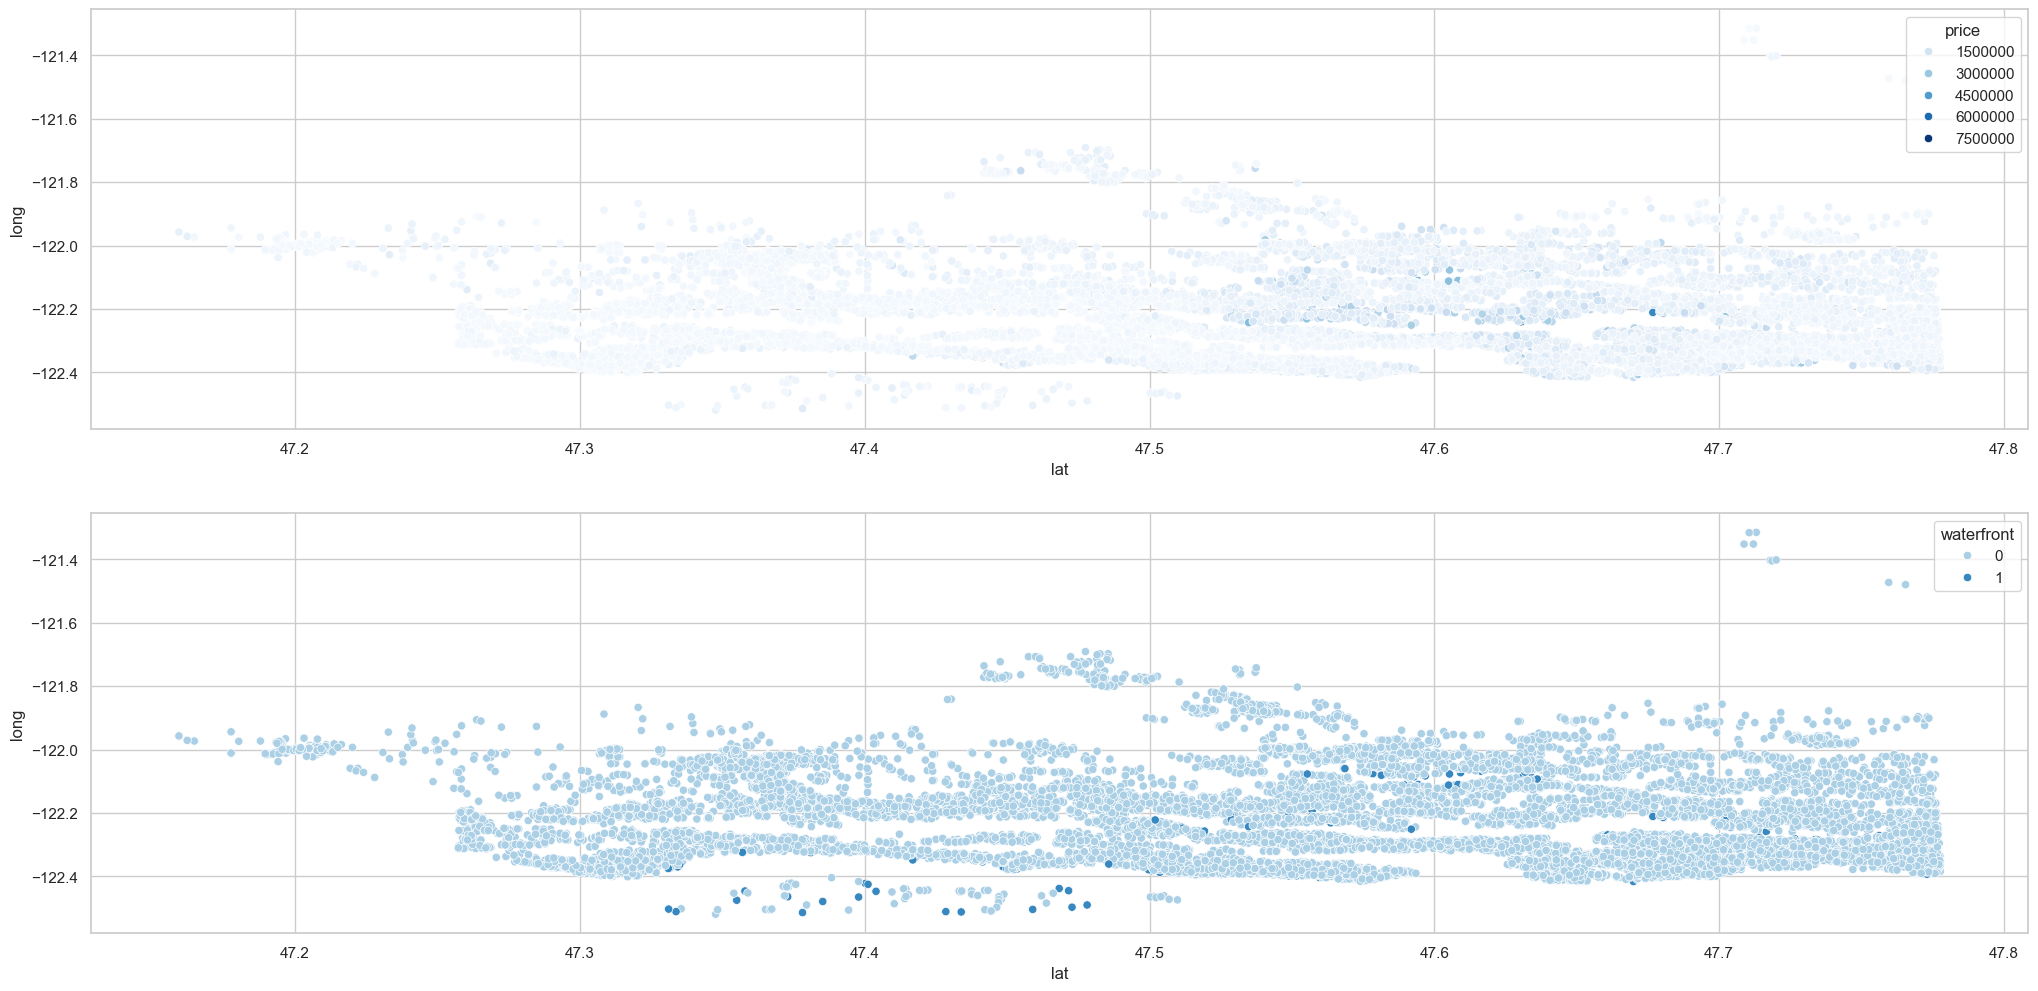

In [20]:
sns.set(style="whitegrid")

fig,axes = plt.subplots(2,1,figsize=(25,12))
sns.scatterplot(train_tsf,x='lat',y='long',hue='price',palette='Blues',ax=axes[0])
sns.scatterplot(train_tsf,x='lat',y='long',hue='waterfront',palette='Blues',ax=axes[1])

plt.show()

- House prices are heavily driven by **spatial location and waterfront presence**, making geographic features and spatial interactions essential components for accurate house price prediction models.

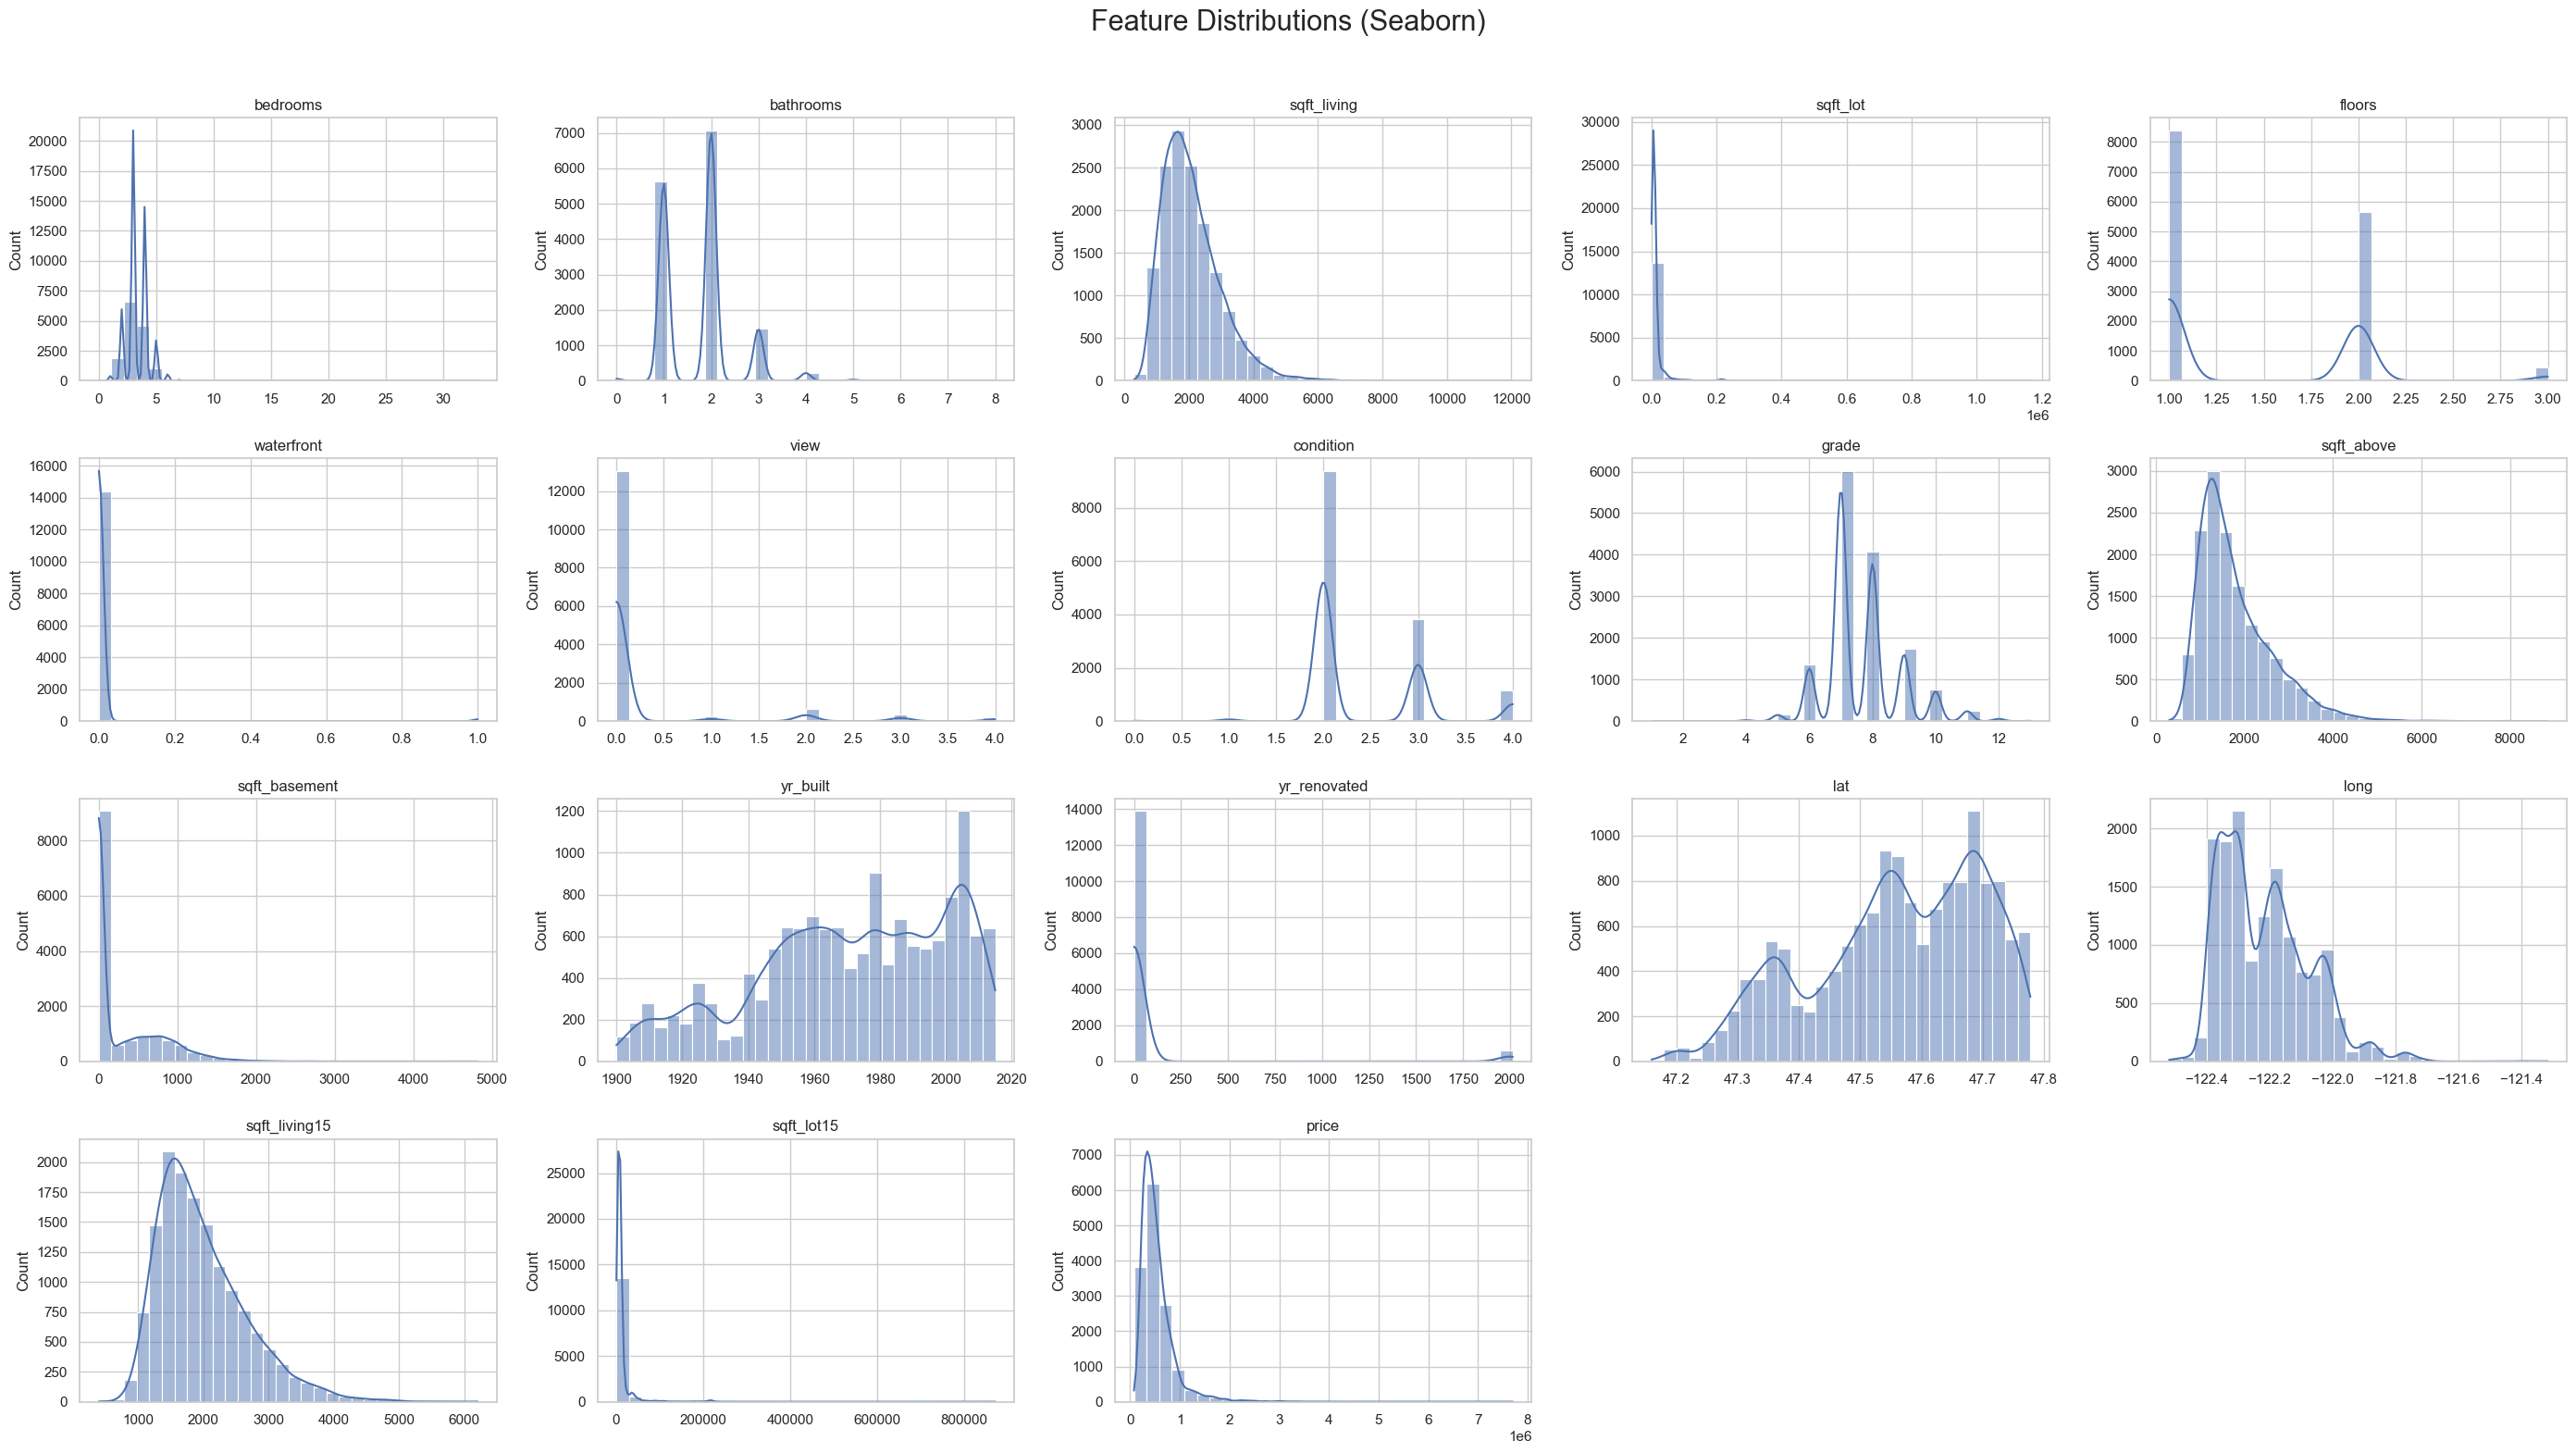

In [21]:


cols = train_tsf.columns
n_cols = 5
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(28, n_rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(
        train_tsf[col],
        bins=30,
        kde=True
    )
    plt.title(col, fontsize=12)
    plt.xlabel("")
    plt.ylabel("Count")

plt.suptitle("Feature Distributions (Seaborn)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


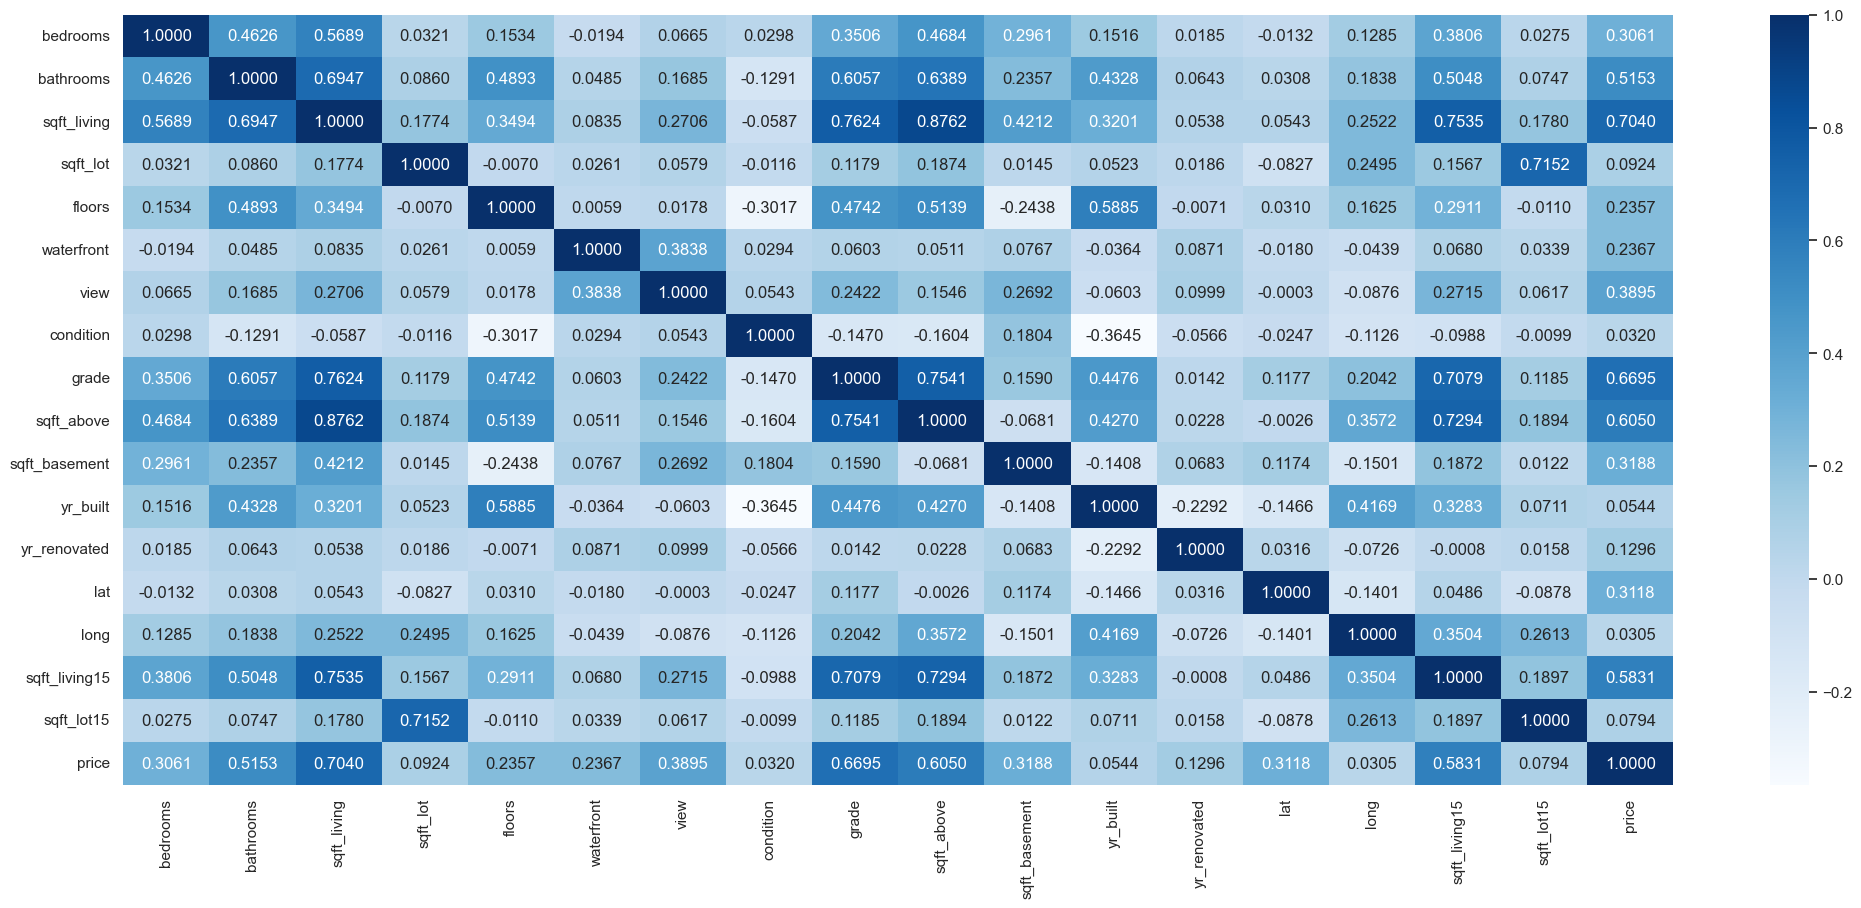

In [27]:
plt.figure(figsize=(25,10))
sns.heatmap(train_tsf.corr(),annot=True,fmt='.4f',cmap='Blues')
plt.show()

----

<br>

## Distribution and Outlier Analysis of Housing Features and Prices


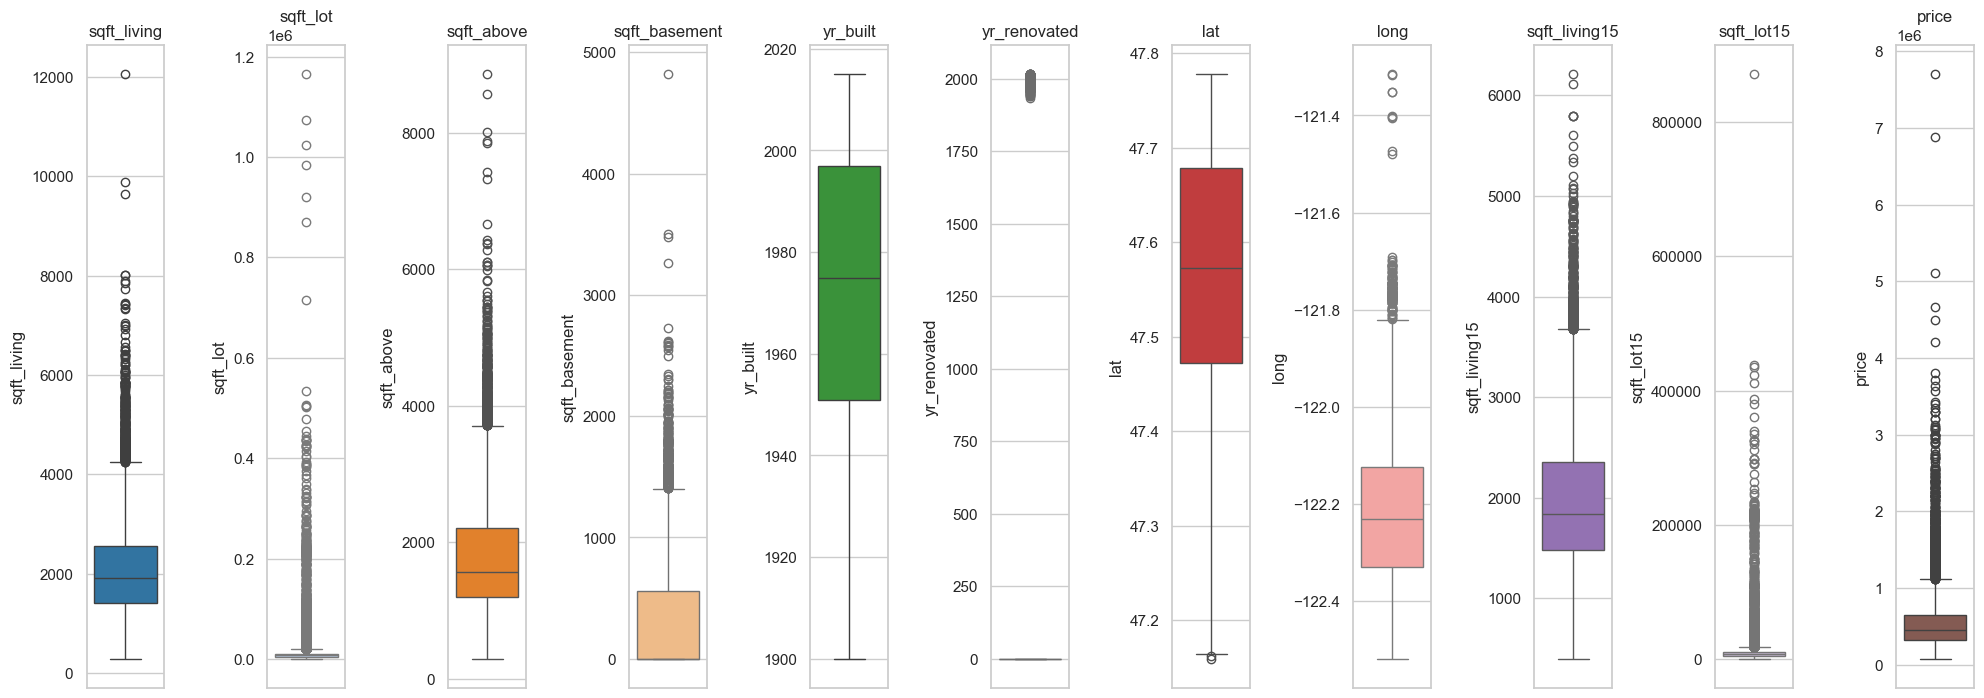

In [14]:
box_cols = [ 'sqft_living', 'sqft_lot',  'sqft_above',
             'sqft_basement', 'yr_built', 'yr_renovated', 'lat',
             'long','sqft_living15', 'sqft_lot15', 'price']
palette = sns.color_palette("tab20", len(box_cols))
fig,axes = plt.subplots(1,11,figsize=(20,7))
ax = axes.flatten()
for x in range(len(box_cols)):
    sns.boxplot(train_tsf,y=box_cols[x],ax=ax[x],color=palette[x]).set_title(f"{box_cols[x]}")
plt.tight_layout()
plt.show()

## Distribution and Outlier Analysis – Summary

- **Strong right skewness** is observed in size-related variables such as `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`, `sqft_living15`, and `sqft_lot15`, indicating the presence of a small number of very large properties.
- **Numerous high-end outliers** appear across most area-based features and in the target variable `price`, reflecting luxury homes that can disproportionately influence model performance.
- **`price`** shows extreme upper outliers, suggesting the need for log transformation or robust modeling techniques.
- **`grade`** is relatively well-concentrated, with most values clustered in a narrow band, implying consistent construction quality for the majority of houses.
- **Year-related features** show different patterns:
  - `yr_built` spans a wide range, indicating both old and newly constructed houses.
  - `yr_renovated` is heavily zero-inflated, meaning most houses have not been renovated.
- **Geographical features (`lat`, `long`)** exhibit tight distributions with minimal spread, confirming stable spatial boundaries and few anomalies.
- Overall, the distributions highlight the importance of **outlier treatment, feature scaling, and potential log transformations** before applying predictive models.

**Key takeaway:**  
The dataset contains significant skewness and outliers in numerical features, especially those related to property size and price, which must be addressed to build robust and reliable house price prediction models.


---
<br>

##  Categorical Feature Distribution and Residential Property Composition


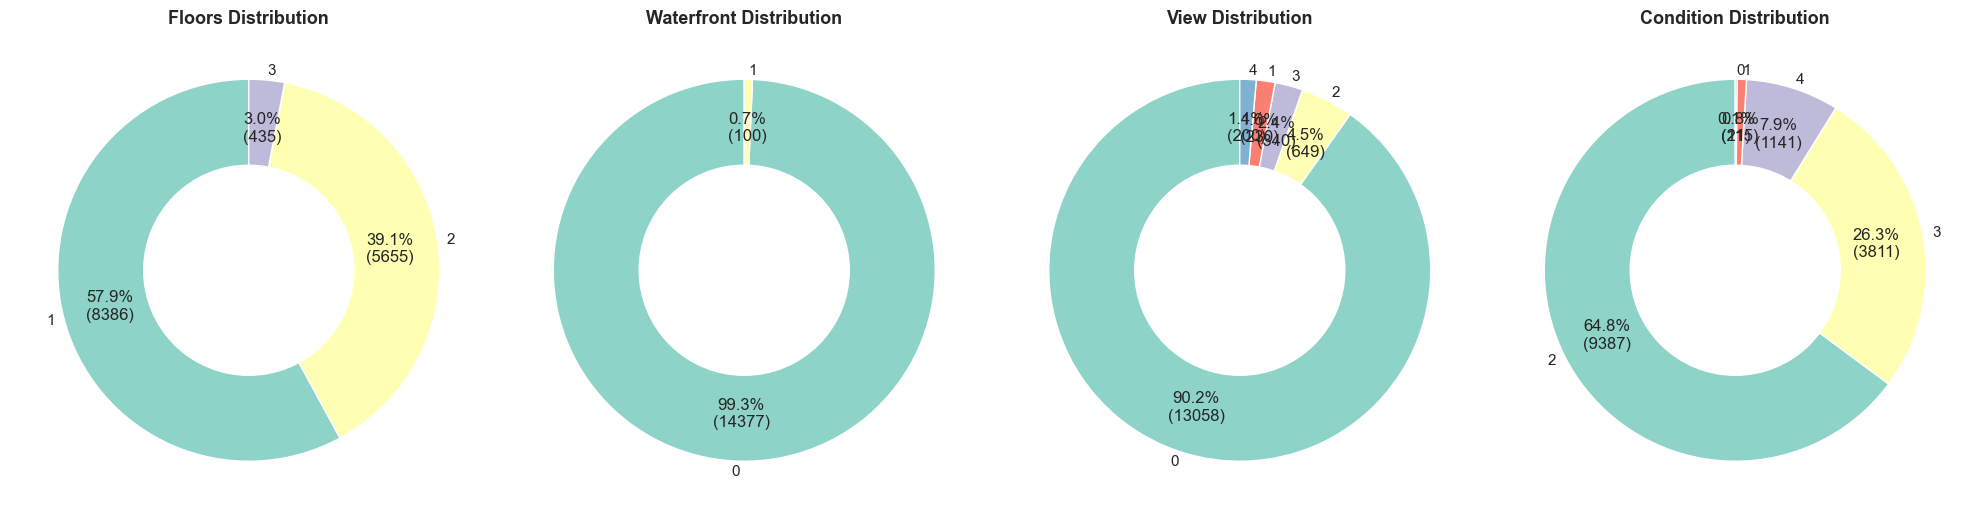

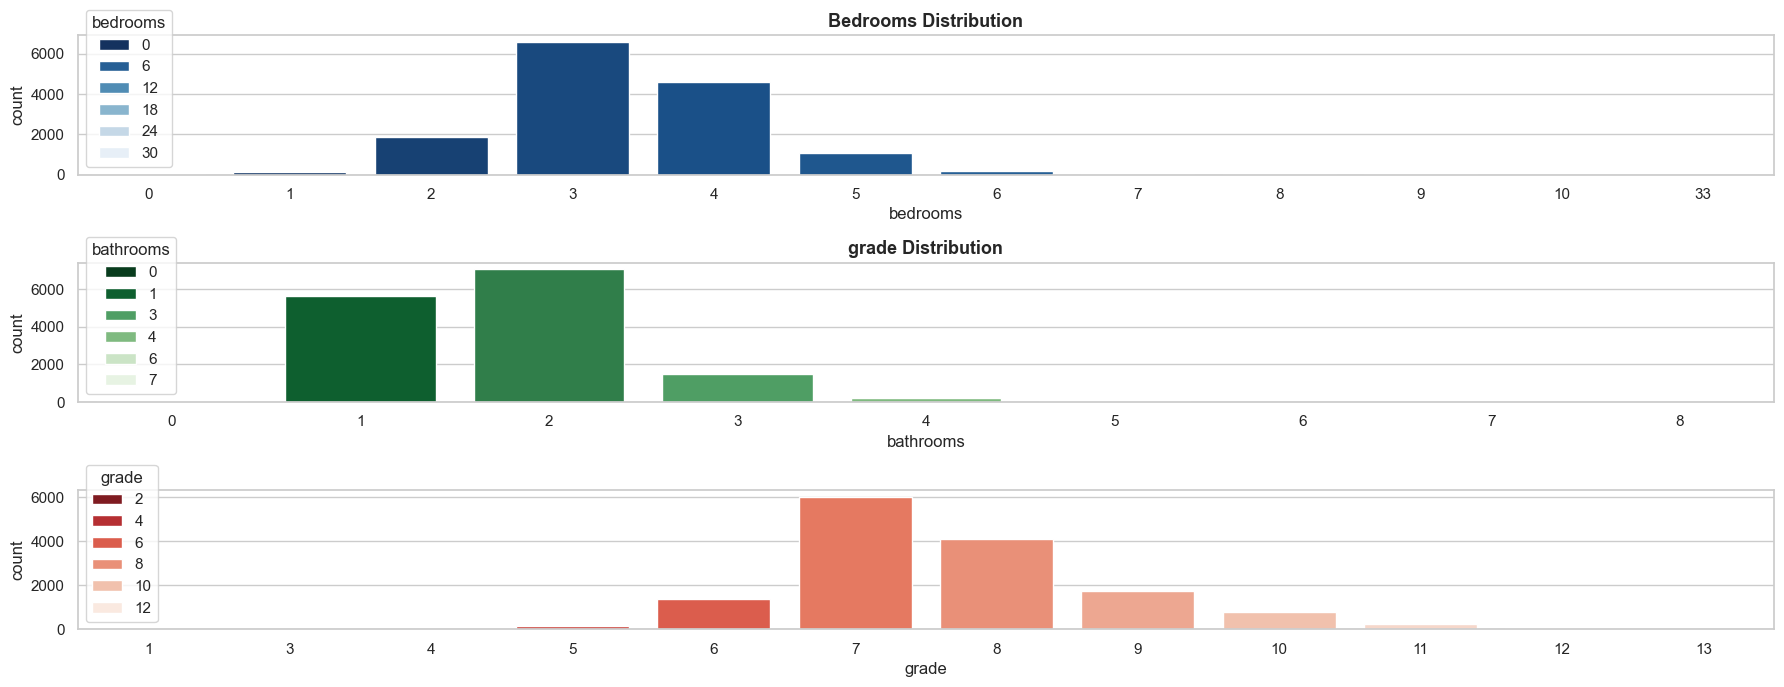

In [15]:
pie_cols = ['floors', 'waterfront', 'view', 'condition']
colors = plt.cm.Set3.colors

fig, axes = plt.subplots(1, len(pie_cols), figsize=(20, 6))

for i, col in enumerate(pie_cols):
    value_counts = train_tsf[col].value_counts().sort_values(ascending=False)
    total = value_counts.sum()

    wedges, texts, autotexts = axes[i].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({int(p*total/100)})',
        startangle=90,
        colors=colors,
        pctdistance=0.75,
        labeldistance=1.05,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )

    # Donut style
    centre_circle = plt.Circle((0, 0), 0.55, fc='white')
    axes[i].add_artist(centre_circle)

    axes[i].set_title(
        f"{col.capitalize()} Distribution",
        fontsize=13,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 1, figsize=(18, 7))
ax = axes.flatten()

sns.countplot(
    train_tsf,
    x='bedrooms',
    hue='bedrooms',
    ax=ax[0],
    palette="Blues_r"
)
ax[0].set_title("Bedrooms Distribution", fontsize=13, fontweight="bold")

sns.countplot(
    train_tsf,
    x='bathrooms',
    hue='bathrooms',
    ax=ax[1],
    palette="Greens_r"
)
ax[1].set_title("Bathrooms Distribution", fontsize=13, fontweight="bold")
sns.countplot(
    train_tsf,
    x='grade',
    hue='grade',
    ax=ax[2],
    palette="Reds_r"
)
ax[1].set_title("grade Distribution", fontsize=13, fontweight="bold")


plt.tight_layout()
plt.show()


### Key Observations

- **Floors Distribution**
  - The housing stock is dominated by **single-floor homes**, followed by **two-floor properties**.
  - Homes with three or more floors are rare, reflecting a predominantly **low-rise residential market**.

- **Waterfront Distribution**
  - The dataset is **extremely imbalanced**, with almost all properties lacking waterfront access.
  - Although rare, waterfront homes represent a **premium segment** likely to exert a strong influence on prices.

- **View Distribution**
  - A vast majority of houses have **no scenic view**.
  - Higher view ratings (1–4) occur infrequently, indicating strong class imbalance and limited premium-view properties.

- **Condition Distribution**
  - Most houses fall into **average to good condition** categories.
  - Very poor and excellent conditions are uncommon, suggesting relatively consistent housing quality.

- **Bedrooms Distribution**
  - **3-bedroom and 4-bedroom homes** are the most common configurations.
  - Extremely high bedroom counts are rare and behave as **outliers**, possibly representing atypical or luxury properties.

- **Bathrooms Distribution**
  - Properties with **1–2 bathrooms** dominate the dataset.
  - The count drops sharply beyond this range, reinforcing the prevalence of mid-sized family homes.

- **Grade Distribution**
  - The majority of houses fall within **grade 7 and 8**, indicating **average to slightly above-average construction quality**.
  - Very low and very high grades are scarce, showing limited extremes in build quality.

### Modeling Insights

- Several categorical features (`waterfront`, `view`, `condition`) exhibit **strong class imbalance**, requiring careful encoding strategies.
- Rare categories may need **grouping or regularization** to prevent biased learning.
- Since standard residential properties dominate the data, models will primarily learn patterns from these homes.
- Premium features, though scarce, should be preserved carefully as they can significantly impact house price predictions.

**Overall takeaway:**  
The dataset represents a realistic housing market dominated by standard residential properties, with a small but important set of premium features that require thoughtful handling during modeling to ensure robust and unbiased predictions.

<br>

---



## Relationship Between House Price and Area-Based Features


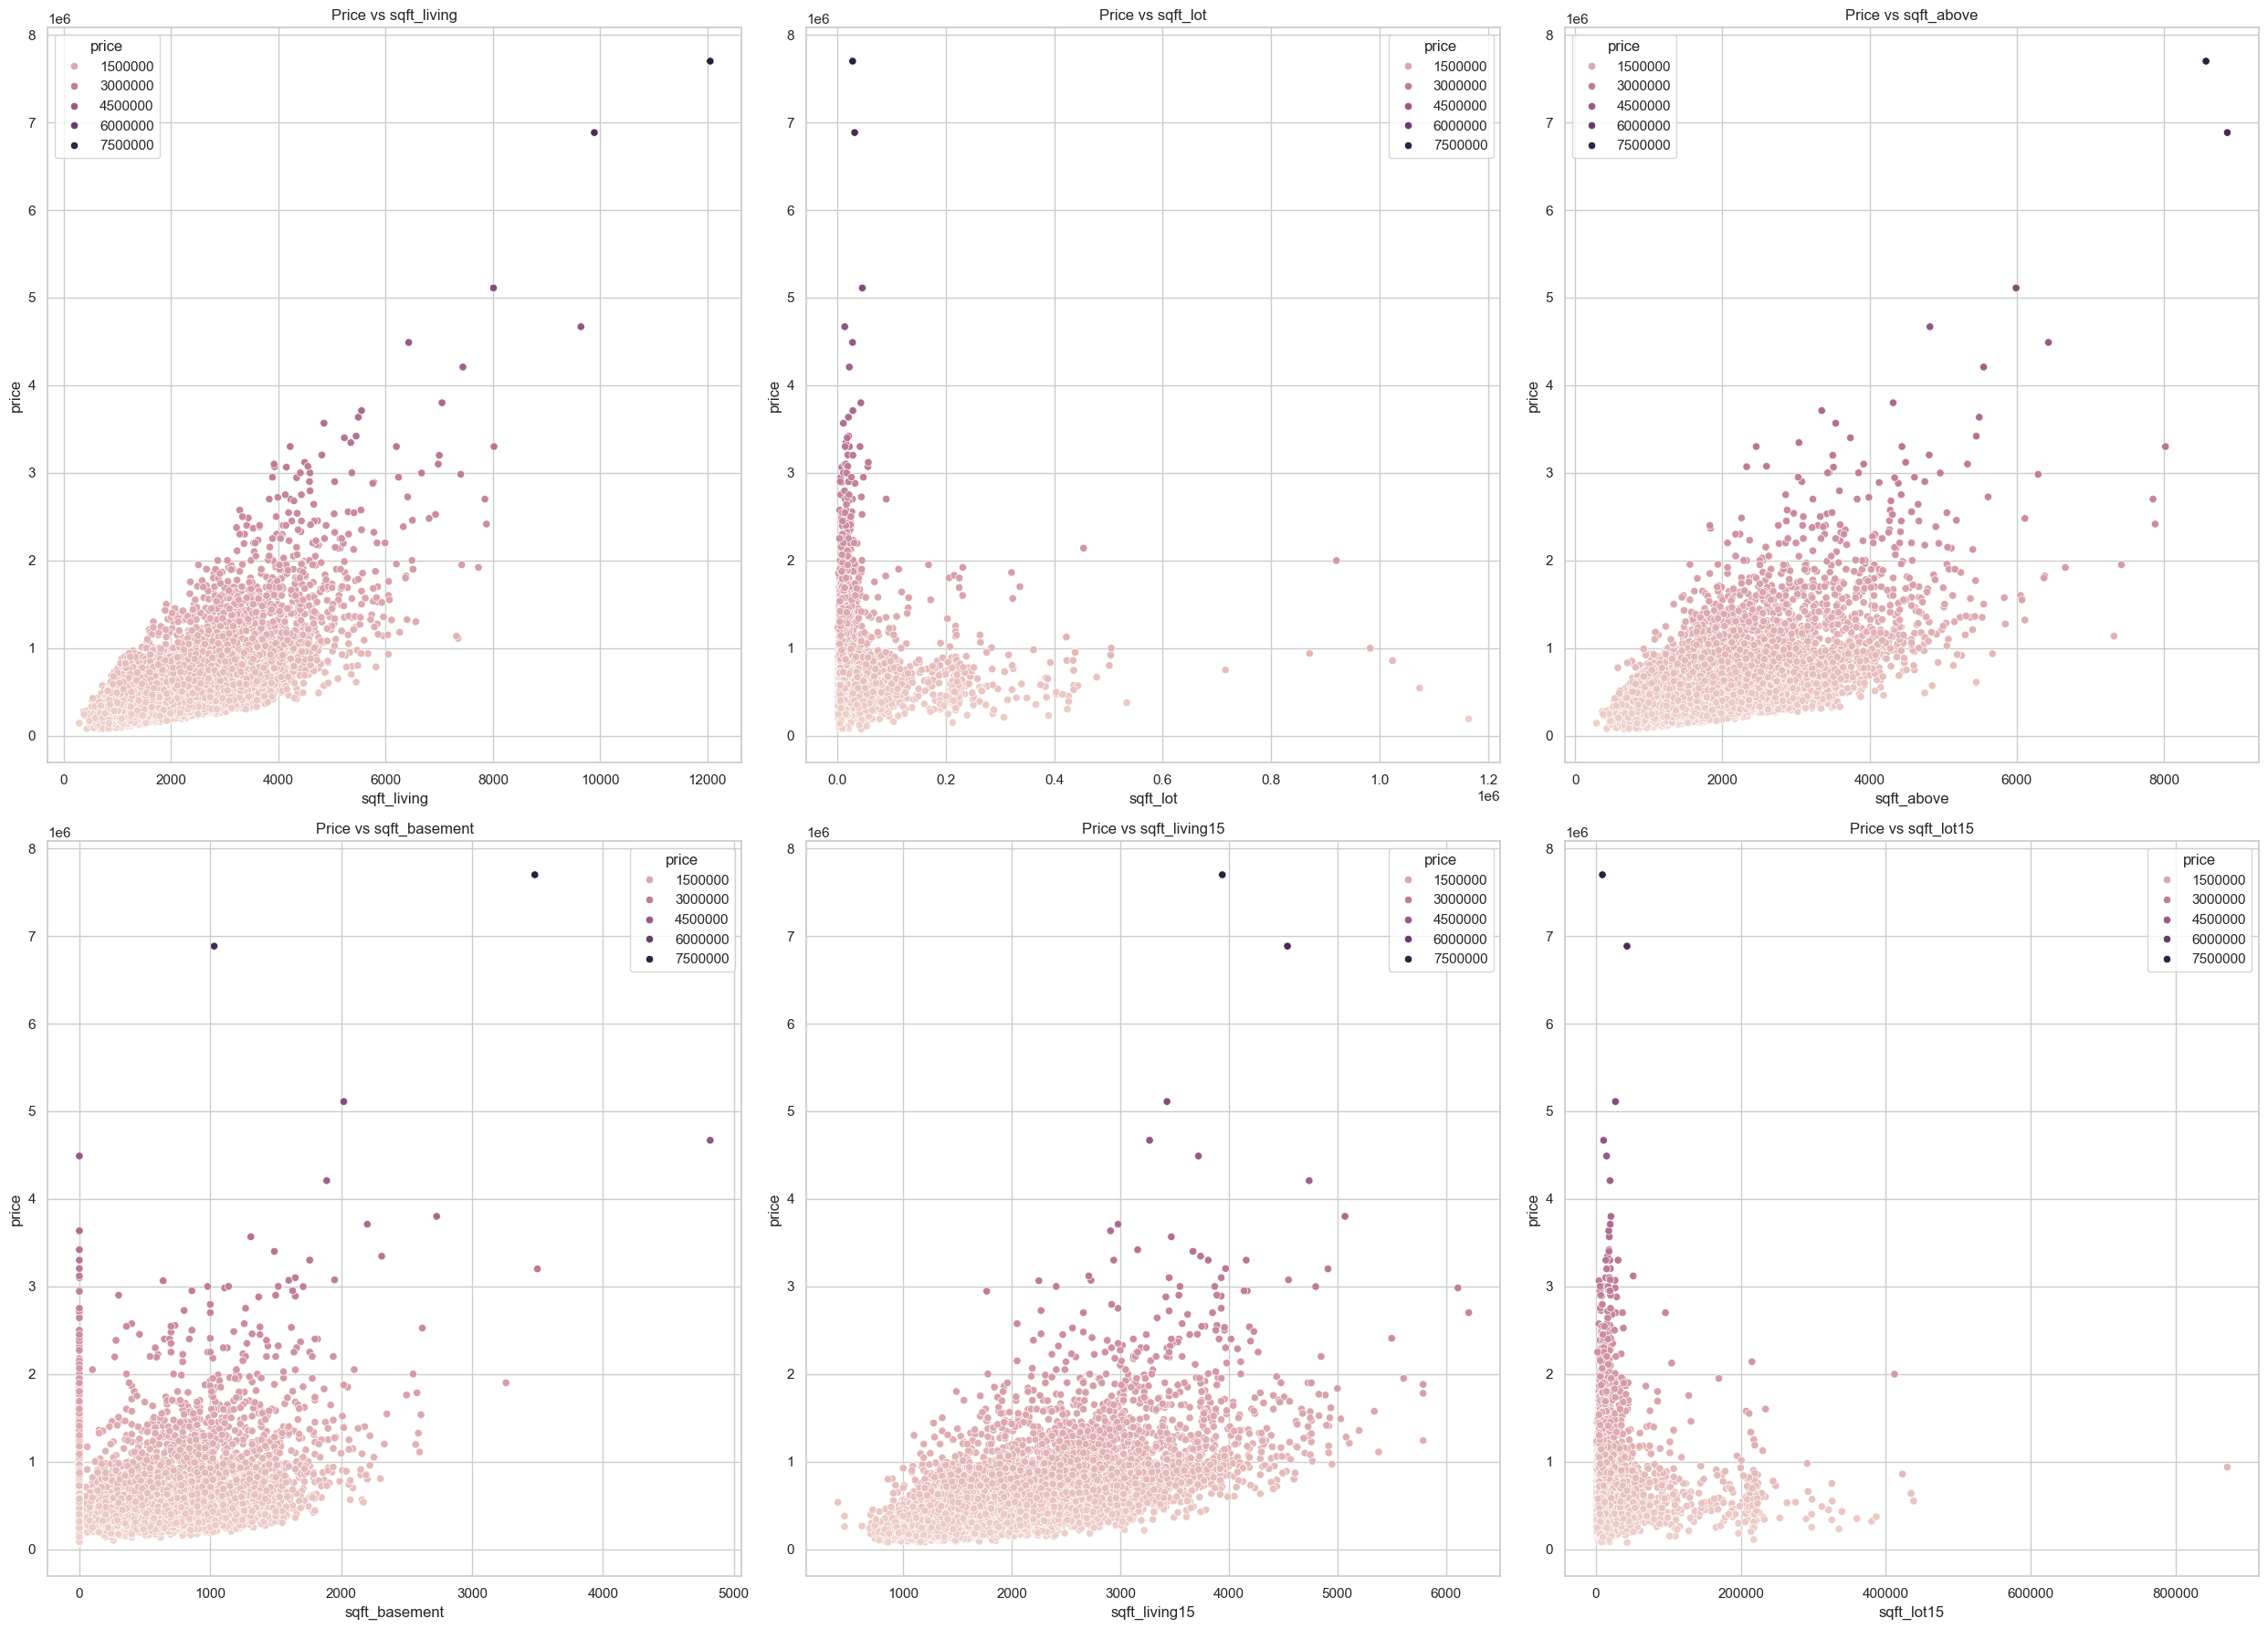

In [16]:
fig,axes= plt.subplots(2,3,figsize=(25,18))
ax = axes.flatten()
price_vs_cols = ['sqft_living','sqft_lot','sqft_above','sqft_basement','sqft_living15','sqft_lot15']
for ax,col in zip(ax,price_vs_cols):
    sns.scatterplot(train_tsf,x=col,y='price',hue='price',ax=ax).set_title(f"Price vs {col}")
plt.tight_layout()
plt.show()


### Summary & Insights

- **Living area features** (`sqft_living`, `sqft_above`, `sqft_living15`) show a **strong positive relationship** with house price, indicating that larger living spaces generally command higher prices.
- **Lot size variables** (`sqft_lot`, `sqft_lot15`) exhibit a **weak and scattered relationship** with price, suggesting that lot size alone is not a strong predictor without considering location and other attributes.
- **Basement area (`sqft_basement`)** shows a **moderate positive trend**, with homes having larger basements often priced higher, though variability remains high.
- High-price **outliers** are present across all plots, especially for large living areas, highlighting the influence of luxury properties.
- The widening spread of prices as square footage increases indicates **heteroscedasticity**, which may affect linear modeling assumptions.

**Key takeaway:**  
House prices are more strongly driven by **usable living space** than by raw land size, emphasizing the importance of interior area features and the need for outlier handling and potential transformations during modeling.


---

## Bedrooms + Bathrooms vs Price Across Different Floor Configurations


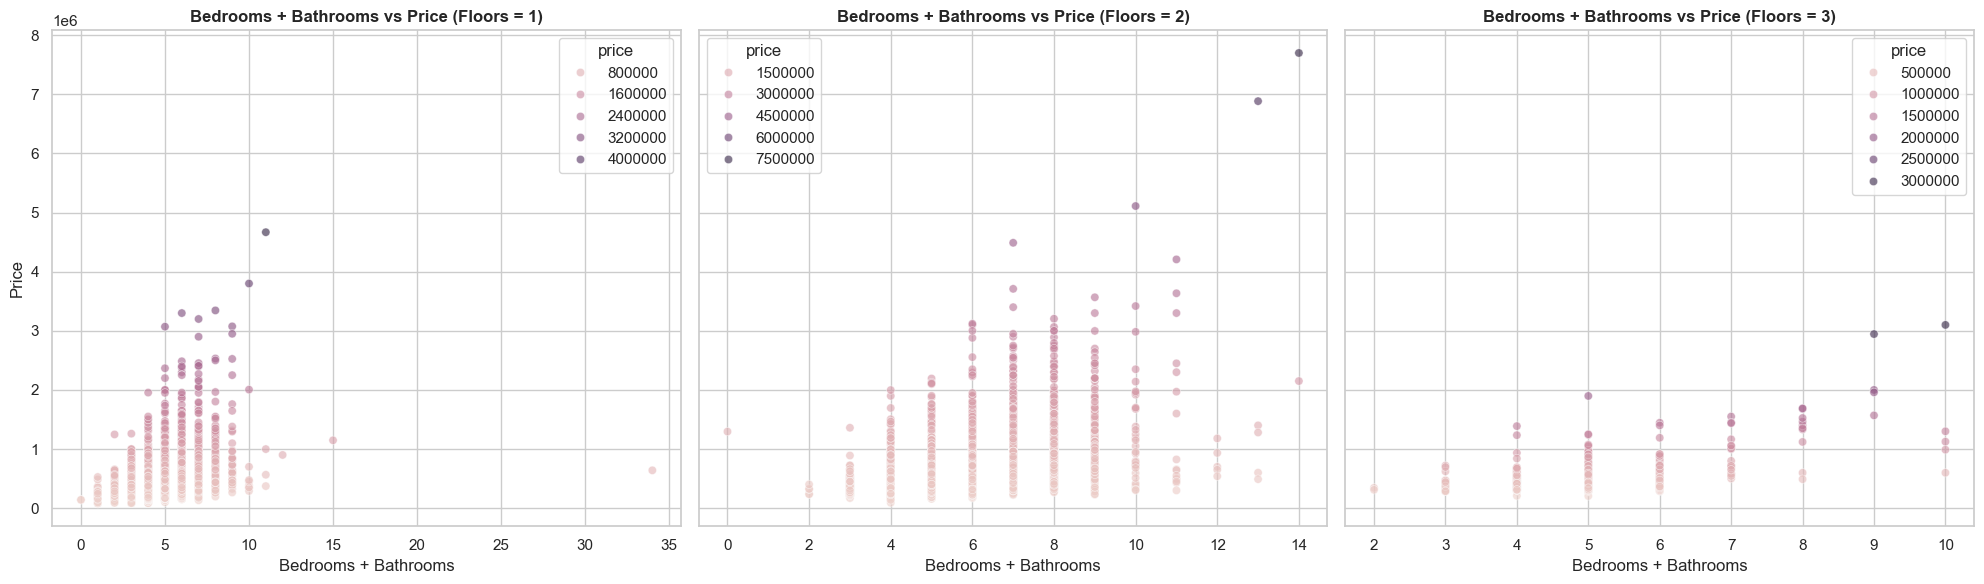

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

floors_list = [1, 2, 3]

for i, floor in enumerate(floors_list):
    subset = train_tsf[train_tsf['floors'] == floor]
    
    sns.scatterplot(
        x=subset['bedrooms'] + subset['bathrooms'],
        y=subset['price'],
        hue=subset['price'],
        alpha=0.6,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Bedrooms + Bathrooms vs Price (Floors = {floor})", 
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Bedrooms + Bathrooms")
    axes[i].set_ylabel("Price")

plt.tight_layout()
plt.show()


### Summary & Insights

- Across all floor categories, **house price generally increases with the combined number of bedrooms and bathrooms**, indicating that overall room capacity is a strong driver of property value.
- **Single-floor homes (Floors = 1)** are concentrated at lower room counts and prices, with a few high-priced outliers, suggesting limited scalability in value for single-level layouts.
- **Two-floor homes (Floors = 2)** show the **widest spread in both room counts and prices**, indicating greater design flexibility and stronger price appreciation as room capacity increases.
- **Three-floor homes (Floors = 3)** are relatively rare and tend to appear at higher room counts, with prices generally higher than single-floor homes but less dispersed than two-floor properties.
- The increasing spread of prices at higher room counts highlights **non-linear effects and potential interaction** between floor count and room configuration.

**Key takeaway:**  
The relationship between room count and price is influenced by the number of floors, with multi-floor homes—especially two-floor properties—exhibiting stronger price variation and higher valuation potential.


---

# Final Summary & Insights

### Overall Data Characteristics
- The dataset shows **strong right skewness** in most size-related numerical features (`sqft_living`, `sqft_above`, `sqft_basement`, `sqft_lot`, and neighborhood equivalents), indicating the presence of a small number of very large properties.
- **High-end outliers**, especially in `price`, are prominent and reflect luxury homes that can disproportionately influence model behavior.
- **Geographical features (`lat`, `long`)** are tightly distributed, suggesting stable spatial boundaries with minimal anomalies.
- **Year-based features** show mixed behavior:
  - `yr_built` spans a wide range, capturing both old and modern constructions.
  - `yr_renovated` is heavily zero-inflated, indicating most houses have never been renovated.

---

### Categorical & Structural Feature Insights
- The housing market is dominated by **standard residential properties**:
  - **1–2 floor homes**, **3–4 bedrooms**, and **1–2 bathrooms** are the most common configurations.
- **Waterfront and view features are extremely imbalanced**:
  - Most houses lack waterfront access or scenic views.
  - Though rare, these premium features likely have a **strong positive impact on price**.
- **Condition and grade** are concentrated around average values:
  - Most houses fall into **average to good condition**.
  - Grades cluster around **7–8**, indicating average to slightly above-average construction quality.

---

### Price Relationships
- **Living area features** (`sqft_living`, `sqft_above`, `sqft_living15`) exhibit a **strong positive relationship** with house price.
- **Lot size features** (`sqft_lot`, `sqft_lot15`) show a **weak and scattered relationship** with price, suggesting land size alone is not a strong predictor.
- **Basement area** has a moderate positive association with price but with high variability.
- As square footage increases, price variability widens, indicating **heteroscedasticity** and non-linear effects.

---

### Floors, Rooms, and Price Interaction
- House price generally **increases with the combined number of bedrooms and bathrooms**.
- **Single-floor homes** are concentrated at lower room counts and prices, with limited value scalability.
- **Two-floor homes** show the **widest spread in prices**, indicating greater flexibility and higher valuation potential.
- **Three-floor homes** are rare, typically appear at higher room counts, and are priced higher than single-floor homes but show less variation than two-floor properties.

---
### Modeling Implications
- Strong **class imbalance** in categorical features (`waterfront`, `view`, `condition`) requires careful encoding or grouping.
- Outliers and skewed distributions suggest the need for **log transformations, robust models, or outlier treatment**.
- Since standard homes dominate the dataset, models will primarily learn from them, making it crucial to preserve premium-feature signals.
- Potential **feature interactions** (e.g., floors × rooms, living area × price) should be considered for improved performance.

---

### Final Takeaway
The dataset represents a **realistic housing market** dominated by standard residential properties, with a small but influential segment of premium homes. Building robust house price prediction models will require thoughtful handling of skewness, outliers, class imbalance, and non-linear relationships—particularly those driven by usable living space and multi-floor configurations.

In [18]:
X_train_tsf = train_tsf.drop('price',axis=1)
X_test_tsf = test_tsf.drop('price',axis=1)
y_train = train_tsf.price
y_test= test_tsf.price

In [19]:
print(X_train_tsf.shape,y_train.shape)
print(X_test_tsf.shape,y_test.shape)

(14478, 17) (14478,)
(7133, 17) (7133,)


In [20]:
# -------- baseline ----------
random_state = 42
models = {
    "lr":LinearRegression(),
    "rfr":RandomForestRegressor(random_state=random_state),
    "cat":CatBoostRegressor(verbose=False,random_state=random_state),
    "lgbmr":LGBMRegressor(random_state=random_state)
}

In [21]:
evaluate_df = evaluate(X_train_tsf,X_test_tsf,y_train,y_test,models)
evaluate_df

Training on fold [0/5]

bestTest = 0.8856141412
bestIteration = 999

Training on fold [1/5]

bestTest = 0.9053281952
bestIteration = 999

Training on fold [2/5]

bestTest = 0.9039624176
bestIteration = 998

Training on fold [3/5]

bestTest = 0.8878893992
bestIteration = 998

Training on fold [4/5]

bestTest = 0.8958390283
bestIteration = 999

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2234
[LightGBM] [Info] Number of data points in the train set: 14478, number of used features: 17
[LightGBM] [Info] Start training from score 537788.429479


,model,test_r2,mse,cv_mean_r2,cv_std_r2
0,cat,0.8957,1.561249e+10,0.8957,0.0090
1,lgbmr,0.8682,1.973571e+10,0.8839,0.0115
2,rfr,0.8558,2.158946e+10,0.8732,0.0050
3,lr,0.6900,4.641369e+10,0.6970,0.0097


## 📊 Baseline Models Evaluation Results (Raw Data)

The table above summarizes the performance of multiple regression models trained  
**directly on raw features**, without applying any feature engineering.

### 🔍 Metric Overview
- **test_r2**: R² score on the unseen test set (higher is better)
- **mse**: Mean Squared Error on the test set (lower is better)
- **cv_mean_r2**: Average R² score from cross-validation (train set only)
- **cv_std_r2**: Standard deviation of CV R² scores (model stability)

### 🧠 Key Observations (Updated with Cross-Validated CatBoost)

- **CatBoost (`cat`)**
  - Achieves the **highest test R² score (0.8957)**, indicating excellent predictive
    performance on unseen data.
  - Native CatBoost cross-validation yields a **CV mean R² of 0.8957** with a
    **low standard deviation (0.0090)**, confirming **strong generalization and
    stable behavior across folds**.
  - With both test and CV performance aligned, CatBoost can now be considered
    **a fully validated and reliable model**, not just a test-set leader.

- **LightGBM (`lgbmr`)**
  - Shows **strong and consistent performance**, with a **CV mean R² of 0.8839**
    and low variance (0.0115).
  - Although its test R² (0.8682) is slightly lower than CatBoost, the high CV score
    confirms **robust generalization**.
  - Remains a **very dependable baseline**, especially valued for its stability.

- **Random Forest (`rfr`)**
  - Delivers **solid performance** with a test R² of **0.8558** and a CV mean R² of
    **0.8732**.
  - The **lowest CV standard deviation (0.0050)** indicates highly stable predictions,
    though overall accuracy is slightly below boosting-based models.

- **Linear Regression (`lr`)**
  - Performs significantly worse, with a test R² of **0.6900** and high error.
  - Confirms that **linear assumptions are insufficient** for capturing the complex,
    non-linear structure of housing price data.

### 📌 Overall Conclusion

- **Tree-based ensemble models** clearly outperform linear regression when trained on
  raw features.
- With the addition of **native cross-validation**, **CatBoost now stands out as the
  best-performing and well-validated model**, achieving the highest test and CV R².
- **LightGBM remains a strong and reliable alternative**, offering excellent
  generalization with slightly lower peak performance.
- Both CatBoost and LightGBM are strong candidates for **feature engineering,
  hyperparameter tuning, and final model selection**, while Random Forest serves as a
  stable but secondary option.


In [5]:
from transformers import PreFEKNNImputer,featureEngineering

In [6]:
datahandling = Pipeline([
    ('imputer',PreFEKNNImputer()),
    ('fe',featureEngineering()),
    ('encode',feature_ordinal_encoding()),
    ('drop',DropColumns(cols=['id','date','zipcode']))
])

In [7]:
datahandling.fit(train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('fe', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_neighbors,12
,weights,'distance'
,cols,"['id', 'date', ...]"


In [25]:
train_tsf2 = datahandling.transform(train)
test_tsf2 = datahandling.transform(test)

In [28]:
X_train2 = train_tsf2.drop('price',axis=1)
X_test2 = test_tsf2.drop('price',axis=1)
y_train2 = train_tsf2.price
y_test2= test_tsf2.price

In [29]:
evaluate_df2 = evaluate(X_train2,X_test2,y_train2,y_test2,models)
evaluate_df2

Training on fold [0/5]

bestTest = 0.8862630551
bestIteration = 997

Training on fold [1/5]

bestTest = 0.9026175478
bestIteration = 999

Training on fold [2/5]

bestTest = 0.9009474302
bestIteration = 994

Training on fold [3/5]

bestTest = 0.8955599203
bestIteration = 996

Training on fold [4/5]

bestTest = 0.8926346687
bestIteration = 999

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2352
[LightGBM] [Info] Number of data points in the train set: 14480, number of used features: 19
[LightGBM] [Info] Start training from score 537789.045718


,model,test_r2,mse,cv_mean_r2,cv_std_r2
0,cat,0.8996,1.503723e+10,0.8956,0.0066
1,lgbmr,0.8675,1.984371e+10,0.8816,0.0132
2,rfr,0.8565,2.149255e+10,0.8721,0.0044
3,lr,0.6901,4.640621e+10,0.6967,0.0099


### 🔹 After Feature Engineering 
- **CatBoost**
  - Achieves the **highest test R² (0.8996)**, showing a clear improvement after feature engineering.
  - Native cross-validation yields a **CV mean R² of 0.8956** with a **low standard deviation (0.0066)**.
  - Close alignment between test and CV scores confirms **strong generalization and robustness**.
  - Feature engineering has **positively contributed**, even if the gain is incremental.

- **LightGBM**
  - Test R² ≈ **0.8675**, showing a slight decline compared to the raw-feature baseline.
  - **CV mean R² ≈ 0.8816** with moderate variability (0.0132).
  - Continues to generalize well, but **benefits less from the applied feature engineering** than CatBoost.

- **Random Forest**
  - Test R² ≈ **0.8565**
  - CV mean R² ≈ **0.8721** with very low variance (0.0044).
  - Remains stable, but feature engineering provides **minimal performance improvement**.

- **Linear Regression**
  - No meaningful improvement observed.
  - Reinforces that **linear models cannot capture the dataset’s non-linear structure**, even with engineered features.

---

### 🧠 Key Insights

- Feature engineering **does not dramatically increase test R²**, but:
  - It **improves model robustness**, especially for CatBoost.
- **CatBoost now emerges as both the best-performing and best-validated model**, with:
  - Highest test R²
  - Highest CV mean R²
  - Lowest CV standard deviation among boosting models
- **LightGBM remains a strong alternative**, but its relative advantage decreases after feature engineering.
- **Random Forest** continues to offer stable but comparatively weaker performance.
- **Linear Regression** consistently underperforms.

---

### ✅ Final Model Assessment

- **Best generalizable model:** **CatBoost**
- **Best test performance:** **CatBoost**
- **Strong secondary option:** **LightGBM**
- **Feature engineering impact:**  
  - Improves **model stability and robustness more than raw accuracy**
  - Validates the effectiveness of the pipeline and engineered features


---

## save base cat model and Preprocessing pipe

In [44]:
import joblib

In [47]:
models['cat'].save_model('base_catboost_house_price_model.cbm')

In [48]:
joblib.dump(datahandling,'DataPreprocessingPipe.pkl')

['DataPreprocessingPipe.pkl']

In [49]:
rf = Pipeline([
    ('datahandling',datahandling),
    ('rf',RandomForestRegressor(n_estimators=350,n_jobs=-1,max_features=0.97,min_samples_leaf=2,max_depth=20,random_state=42))
])

lgbm = Pipeline([
    ('datahandling', datahandling),
    ('lgbm', LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=64,

        subsample=0.8,
        colsample_bytree=0.8,

        min_child_samples=20,
        min_child_weight=1e-3,

        reg_alpha=0.1,
        reg_lambda=1.0,

        objective='regression',
        metric='rmse',

        random_state=random_state,
        verbosity=-1
    ))
])

In [67]:
# Predict
cat_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.071,
    depth=7,
    loss_function='RMSE',
    verbose=False,
    random_state=random_state
)

cat_model.fit(X_train2, y_train2)

y_pred = cat_model.predict(X_test2)    

In [68]:
print("r2 :",r2_score(y_test2,y_pred))
print("rmse",math.sqrt(mean_squared_error(y_test2,y_pred)))

r2 : 0.8999316286482201
rmse 122406.595666173


In [69]:
from catboost import Pool,cv

In [70]:
train_pool = Pool(X_train2,y_train2)

In [75]:
cv_results = cv(
    pool=train_pool,
    params={
    "loss_function": "MAE",
    "eval_metric": "R2",
    "iterations": 1200,
    "learning_rate": 0.071,
    "depth": 8,
    "random_seed": 42,
    "verbose": False
    },
    fold_count=5,
    shuffle=True,
    partition_random_seed=42
)

Training on fold [0/5]

bestTest = 0.8838718691
bestIteration = 1117

Training on fold [1/5]

bestTest = 0.8991580745
bestIteration = 736

Training on fold [2/5]

bestTest = 0.8922664131
bestIteration = 775

Training on fold [3/5]

bestTest = 0.89880641
bestIteration = 1179

Training on fold [4/5]

bestTest = 0.8906634738
bestIteration = 1193



In [76]:
r2_mean_col = [c for c in cv_results.columns if "test" in c.lower() and "r2" in c.lower() and "mean" in c.lower()][0]
r2_std_col  = [c for c in cv_results.columns if "test" in c.lower() and "r2" in c.lower() and "std" in c.lower()][0]

cv_mean_r2 = cv_results[r2_mean_col].iloc[-1]
cv_std_r2 = cv_results[r2_std_col].iloc[-1]

print("CV Mean R2:", round(cv_mean_r2, 4))
print("CV Std R2 :", round(cv_std_r2, 4))


CV Mean R2: 0.8927
CV Std R2 : 0.0062


## Final Observation on Model Performance

Given the **nature and complexity of the house pricing dataset**, the observed improvements from feature engineering and model tuning are **incremental rather than substantial**.

House prices are influenced by a **highly non-linear combination of factors**—such as location, usable living space, structural attributes, and rare premium features (e.g., waterfront, views)—many of which are already well captured by advanced tree-based models. As a result, strong baseline models like CatBoost and LightGBM are able to learn most of the available signal directly from the raw data.

Additionally, the presence of **outliers, skewed distributions, and heterogeneous property types** limits the extent to which simple feature transformations can further improve performance. Consequently, while feature engineering contributes to **better stability and generalization**, it does not lead to dramatic gains in predictive accuracy.

**Overall takeaway:**  
Due to the **intrinsic complexity and saturation of predictive signals in housing data**, model performance improvements are naturally constrained, and marginal gains should be expected even with careful feature engineering and tuning.
